# RSD AND RMSE IN CURVE FITTING

In this notebook, a **polynomial fit** on a given dataset is done and the model's accuracy is evaluated by analyzing the **residuals**.

To assess the fit's quality, two error metrics are done
- **Relative Standard Deviation (RSD)**
- **Relative Root Mean Squared Error (RMSE)**


In [4]:
#Import alias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
#read and check csv
df_1 = pd.read_csv('quadratic_fit_data.csv')
missing_values = df_1.isnull().sum()
print(missing_values)

x    0
y    0
dtype: int64


In [8]:
#Do the polyfit
x = df_1['x']
y = df_1['y']
a,b,c = np.polyfit(x,y,2)
y_fit = a*(x**2)+b*x+c

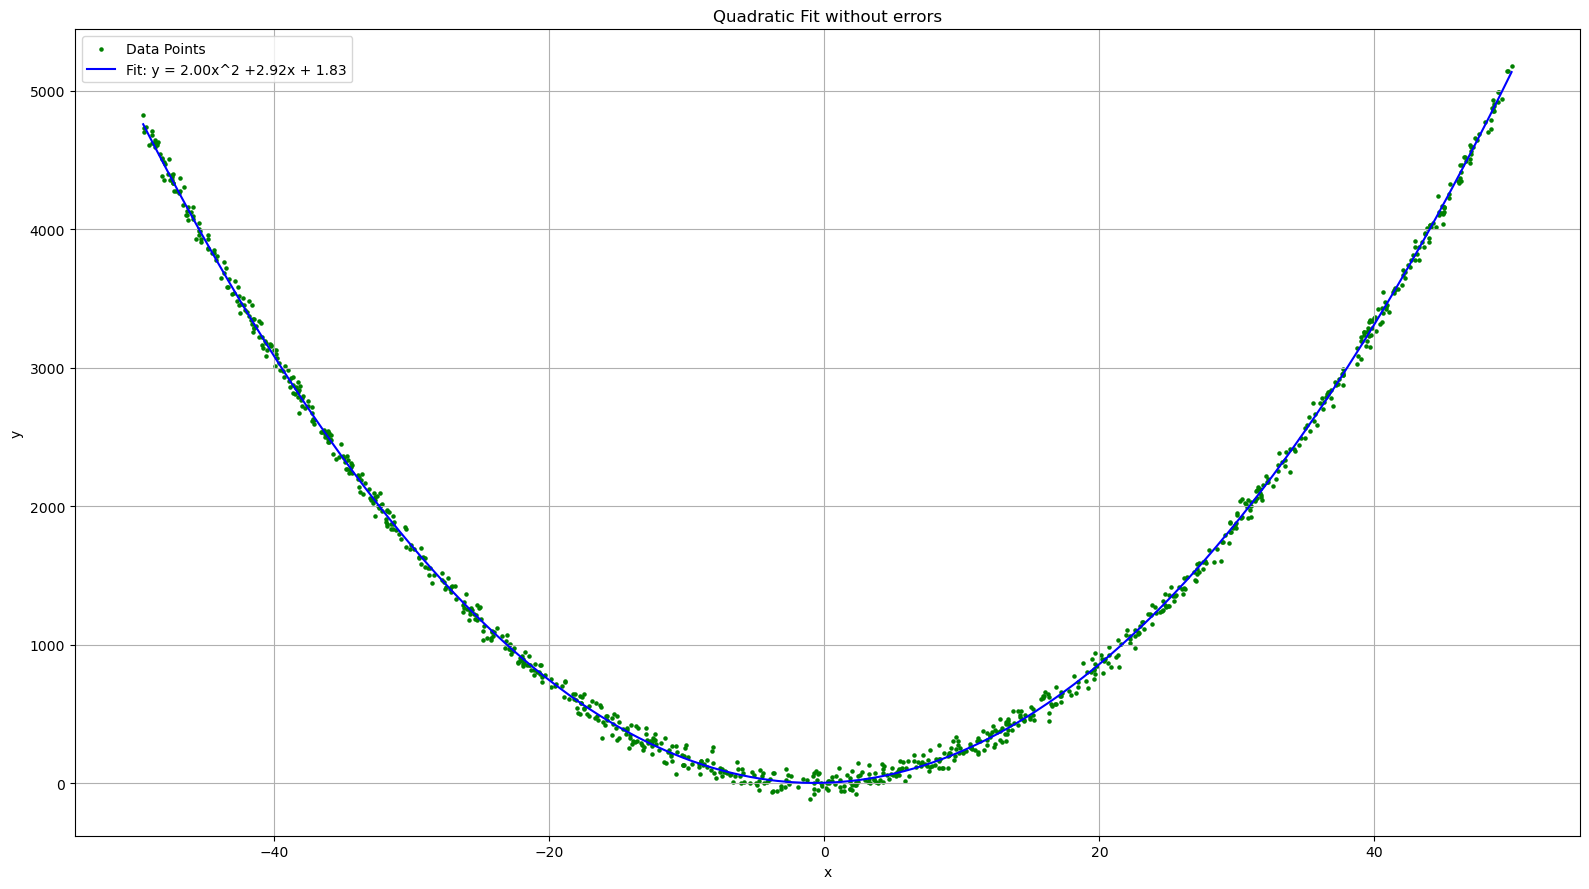

In [10]:
plt.figure(figsize= (16,9))
plt.scatter(x,y, label= 'Data Points', color='green', s=5)
plt.plot(x, y_fit, label=f'Fit: y = {a:.2f}x^2 +{b:.2f}x + {c:.2f}', color='blue')    #.2f part ensures we get only the first two decimal points of slope and intercept
plt.xlabel('x')
plt.ylabel('y')
plt.title('Quadratic Fit without errors')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Residual Error

In curve fitting, a **residual** is the difference between an observed value and the value predicted by the fitted model.
</br> Residuals help us understand how well the model fits the data. Ideally, residuals should:
- Be small in magnitude
- Show no clear pattern when plotted (random scatter)
- Be symmetrically distributed around zero (some of the values will be overestimated(>0) and some will be underestimated(<0)

$$
\text{Residual}_i = y_i - \hat{y}_i
$$
where
</br>($y_i $) is the actual (observed) value
</br>($\hat{y}_i $) is the predicted value from the fitted curve


In [14]:
#Calculating Residuals
residuals = np.subtract(y, y_fit)
df_1['Residuals'] = residuals

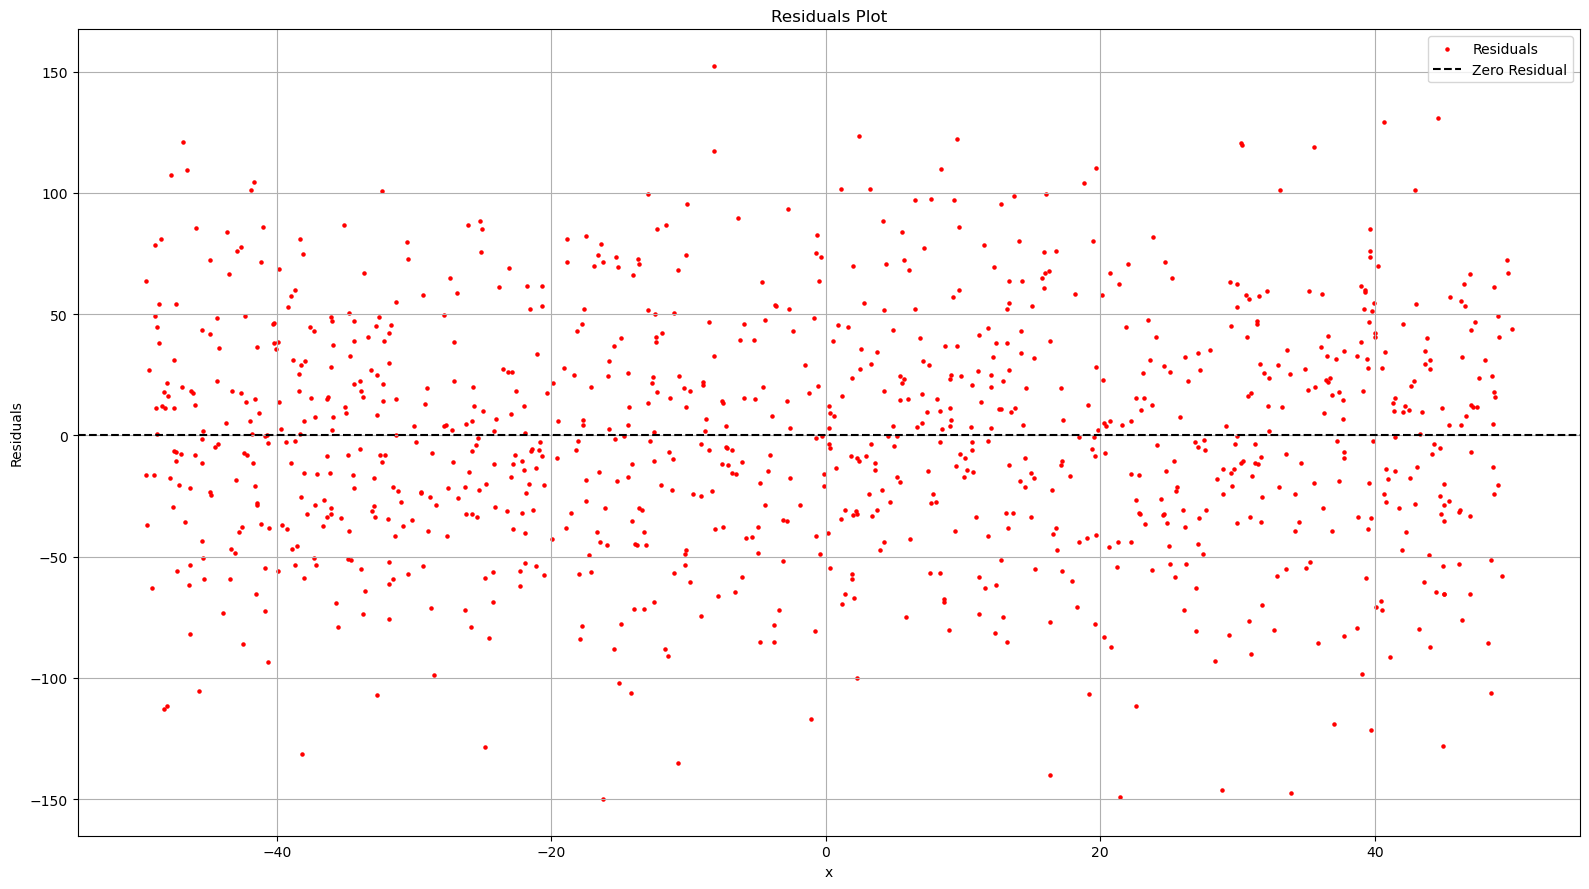

In [16]:
#Plotting the Residuals
plt.figure(figsize=(16, 9))
# Plot residuals (scatter plot)
plt.scatter(x, residuals, label='Residuals', color='red', s=5)
# Add a horizontal line at 0 for reference
plt.axhline(0, color='black', linestyle='--', label='Zero Residual')
# Labels and title for the residuals plot
plt.xlabel('x')
plt.ylabel('Residuals')
plt.title('Residuals Plot')
plt.legend()
plt.grid(True)
plt.tight_layout()
# Show the residuals plot
plt.show()

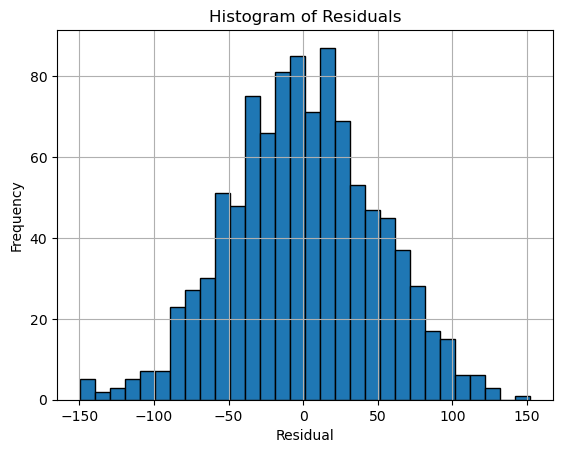

In [18]:
#Plotting Histogram of Residuals
plt.hist(residuals, bins=30, edgecolor='black')
plt.title("Histogram of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

### Data Obtained from a Histogram
A **histogram** provides a visual summary of how residuals (errors) are distributed, assessing the quality of a curve fit.

---
#### 1. **Center (Mean or Mode)**
- The peak of the histogram shows where most residuals lie.
- A good model should have residuals **centered around zero**.

---

#### 2. **Spread (Variance)**
- A **wide histogram** indicates high variance (larger spread in residuals).
- A **narrow histogram** indicates low variance (predictions are closer to true values).

---

#### 3. **Symmetry**
- A **symmetrical** shape (even on both sides of zero) means the model isn’t biased.
- An **asymmetrical** (skewed) shape might indicate consistent over- or under-prediction.

---

#### 4. **Shape (Normality)**
- A **bell-shaped** (normal) curve suggests good model behavior.
- Deviations from normality (e.g., skewed, multiple peaks) may indicate:
  - Model inadequacy.
  - Missing variables.
  - Data issues.

---

#### 5. **Outliers**
- Tall bars far from zero represent **outliers** (large prediction errors).
- Outliers can point to data entry issues or areas where the model performs poorly.

---

### Summary:
If the histogram of residuals is **centered at 0**, **symmetric**, and **bell-shaped**, the fit is likely appropriate. Otherwise, consider:
- Trying a different model (e.g., different polynomial degree).
- Checking data quality or preprocessing.


In [20]:
#Standard deviation of Residuals
#Standard deviation measures the average spread of residuals around zero.
#A smaller standard deviation indicates the model fits the data more closely.
std_residuals = np.std(df_1['Residuals'])
print(f"Standard Deviation of Residuals: {std_residuals}")

Standard Deviation of Residuals: 49.340342226798434


In [22]:
#Relative Standard deviation
mean_residuals = np.mean(df_1['Residuals'])
rsd = (std_residuals/np.abs(mean_residuals))*100
print(f'The relative standard deviation is {rsd} %')


The relative standard deviation is 1.5885879940501332e+16 %


### Sum of Squared Errors (SSE)

**SSE** is a measure of how well your model fits the data. It is calculated by taking the **square of each residual (error)** and summing them up.

#### Formula:

$$
\text{SSE} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

- $ y_i $: Actual data point
- $ \hat{y}_i $: Predicted value from the model
- $ n $: Number of data points

#### Interpretation:
- A **lower SSE** means the model's predictions are closer to the actual values (better fit).
- A **higher SSE** means a worse fit.
- Since residuals are squared, **large errors** have more impact.

#### Notes:
- SSE is sensitive to **outliers** as it squares the high values.
- It is in the **same unit squared** of`y` values.
- It is a **raw** error measure, so it’s useful to compare models on the same dataset, but less informative across different datasets unless normalized.
- SSE varies with number of measurements done
- SSE is the sum of the squares of the residuals


In [24]:
sse = np.sum((residuals)**2)

In [26]:
print(sse)

2434469.3710575867


### RMSE
**RMSE (Root Mean Squared Error)** is a measure of the average magnitude of the errors between predicted values and actual values in a dataset. It calculates the square root of the average of the squared differences (residuals) between the predicted and actual values.
</br>**Root Mean Squared Error** is better for measuring errors as it normalizes the values by dividing the SSE with n and taking it's root over
$$ \text{RMSE} = \sqrt{\frac{\text{SSE}}{n}} $$
**SSE** alone is not enough to interpret a model. When multiple models have been given with the same data points, the one with the least value of the SSE, is the most effective one, but for just a single model, RMSE is to be adopted.

In [46]:
rmse = np.sqrt(np.mean((residuals)**2))
print(rmse)
#alternative is np.sqrt(sse/len(y))

49.34034222679841


**RMSE** has the same unit as y so, it is easier to interpret.
</br> **RMSE** value of approximately equal to 50 means there is an error of 50 units on an average on the measured values
</br> **RMSE Relative** value is to be calculated 
$$ \text{RMSE}_{\text{rel}} = \frac{\text{RMSE}}{\bar{y}} $$

In [54]:
rmse_rel = rmse/np.mean(y)
print(rmse_rel)

0.028953929064538766


In [56]:
#percentage value 
print(rmse_rel*100)

2.8953929064538766


1. Relative RMSE gives a percentage of RMSE relative to the mean of the actual data

2. Relative Standard Deviation (RSD) measures the spread of residuals relative to the mean of the actual data but focuses on variability rather than the actual magnitude of error.

### Conclusion
Based on the low **Relative Standard Deviation** and **Relative RMSE** values, it is clear that the second order fit is a good fit for the given data.
